In [84]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from sklearn import linear_model
import seaborn as sns
import random 
import statistics 
import math 
import scipy as sc
from scipy.stats import chisquare
from collections import Counter

random.seed(42)

### Part 1: A discrete-time model

In this project, we will work with the following Markov model.
The model follows women after they had their breast tumor removed. The cancer may reappear close to the removed tumor. This is called local recur- rence, and the woman enters state 2. The cancer may also reappear distant from where it was operated. This is called distant metastatis. Both things may also occour. Death can occur from any state. In this model, once the death state has been entered, it can never be left again. This means the simulation should be terminated once this state has been reached.

### Task 1

Use the following probability matrix:

In [85]:
P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001],
               [0, 0.986, 0.005, 0.004, 0.005],
               [0, 0, 0.992, 0.003, 0.005],
               [0, 0, 0, 0.991, 0.009],
               [0, 0, 0, 0, 1]])

Assume that one time step equals one month. Simulate 1000 women, all starting in state 1, until death. Summarize the lifetime distribution of the women, after surgery, for example using a histogram. In what proportion of women does the cancer eventually reappear, locally?

In this assignment we want to simulate 1000 women who have had breast cancer and have undergone surgery. There are 5 possible states they can get into after surgery.

• State 1: Healthy after removal of the tumor,

• State 2: Local recurrence of the cancer,

• State 3: Distant recurrence of the cancer,

• State 4: Both local and distant recurrence of the cancer,

• State 5: Death.

In [86]:
n_women = 1000
survival_distribution = []
cancer_local_count = 0
states = []

In [87]:
n_women = 1000
survival_distribution = []
cancer_local_count = 0
states = []

for _ in range(n_women):
    state = 0 
    survivaltime = 0
    had_local = False 

    while state != 4: 
        state = np.random.choice(range(5), p=P[state])
        survivaltime += 1

        if state == 1 or state == 3:  
            had_local = True
            
    if had_local:
        cancer_local_count += 1
        
    states.append(state)
    survival_distribution.append(survivaltime)

Text(0.5, 1.0, 'Lifetime Distribution of Women after Surgery')

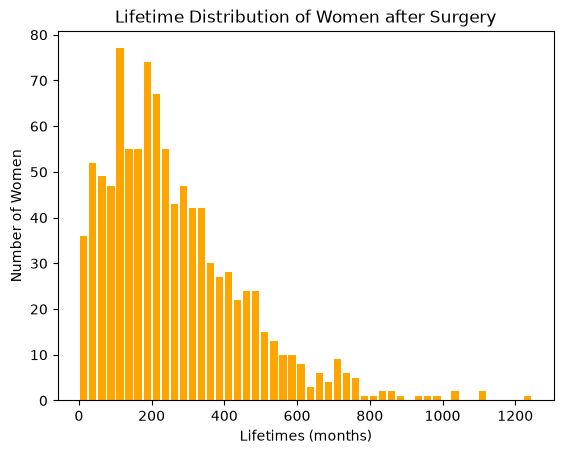

In [88]:
plt.hist(survival_distribution, bins=50, rwidth=0.8, color="orange")
plt.xlabel('Lifetimes (months)')
plt.ylabel('Number of Women')
plt.title('Lifetime Distribution of Women after Surgery')

In [89]:
reapear_locally = cancer_local_count/n_women
print("Median of lifetime distribution of women after Surgery = ",np.median(survival_distribution) )
print("Proportion of women where cancer reapear locally = ", reapear_locally)


Median of lifetime distribution of women after Surgery =  221.0
Proportion of women where cancer reapear locally =  0.67


The histogram shows the distribution of how many months women survive after surgery. The plot is right skewed, meaning that most women survive shorter than the median. We can also conclude that the proportion of women where cancer reappears locally is approx. 70%.